Dataset shape: (178, 13)
Classes: ['class_0', 'class_1', 'class_2']
Samples per class: [59 71 48]
Training samples: 124  Testing samples: 54

Class prior probabilities: [0.3306 0.4032 0.2661]

Accuracy: 1.0

Confusion Matrix:
[[18  0  0]
 [ 0 21  0]
 [ 0  0 15]]

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54

Sample prediction:
Actual class   : class_0
Predicted class: class_0
Probabilities  : [1. 0. 0.]


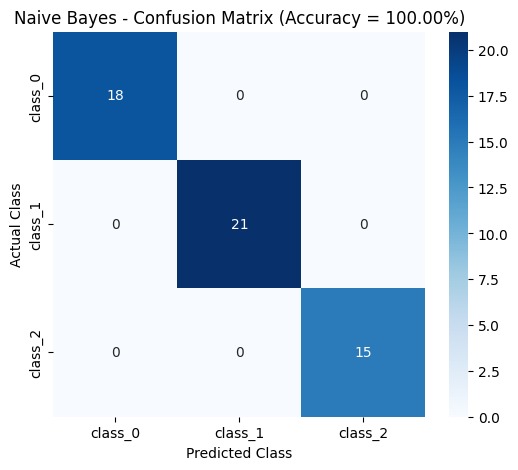

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report

wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target
print("Dataset shape:", X.shape)
print("Classes:", wine.target_names.tolist())
print("Samples per class:", np.bincount(y))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
print("Training samples:", len(X_train), " Testing samples:", len(X_test))

model = GaussianNB()
model.fit(X_train, y_train)

print("\nClass prior probabilities:", np.round(model.class_prior_, 4))

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("\nAccuracy:", round(acc, 4))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=wine.target_names))

sample = X_test.iloc[[0]]
print("Sample prediction:")
print("Actual class   :", wine.target_names[y_test[0]])
print("Predicted class:", wine.target_names[model.predict(sample)[0]])
print("Probabilities  :", np.round(model.predict_proba(sample)[0], 4))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Naive Bayes - Confusion Matrix (Accuracy = "
          f"{acc * 100:.2f}%)")
plt.show()
